In [1]:
#Importing all the necessary Libraries 

# Data handling and manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models and tools
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score

# Common ML algorithms
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Deep Learning (optional but popular)
#import tensorflow as tf
#from tensorflow import keras
#from keras.models import Sequential
#from keras.layers import Dense, Dropout

# System and warning control
import os
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('health1.csv')
df.head()


,country,admin1_region,year,vitamin_a_deficiency_pct,iron_anemia_women15_49_pct,iodine_deficiency_pct,stunting_under5_pct,wasting_under5_pct,underweight_under5_pct,malaria_incidence_per1000,...,cassava_consumption_kg_pc,price_volatility_index,health_risk_index,population_density_per_km2,rural_population_pct,market_demand_index,recommended_crop,climate_risk_index,water_availability_index,agricultural_input_access_index
0,Nigeria,Lagos,2023,17.6,48.0,16.2,35.5,6.7,11.4,288.3,...,79.9,0.13,1.40,373.7,34.3,0.69,Spinach,2.42,0.77,0.26
1,Nigeria,Lagos,2022,16.0,47.4,16.2,34.8,6.1,19.1,178.2,...,71.6,0.25,1.33,164.2,41.9,0.80,Spinach,1.27,0.55,0.45
2,Nigeria,Kano,2023,28.7,41.7,20.9,25.3,9.6,13.1,231.7,...,67.2,0.19,1.27,251.5,57.1,0.77,Orange-fleshed Sweet Potato,2.84,0.48,0.57
3,Nigeria,Kano,2021,18.3,35.2,16.0,23.3,9.7,11.0,100.0,...,96.2,0.18,1.37,695.2,22.6,0.83,Cassava,1.35,0.55,0.29
4,Nigeria,Kaduna,2021,25.2,50.6,17.1,28.7,8.2,23.8,142.9,...,84.1,0.12,1.13,672.7,70.6,0.83,Orange-fleshed Sweet Potato,1.85,0.53,0.72


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          120 non-null    object 
 1   admin1_region                    120 non-null    object 
 2   year                             120 non-null    int64  
 3   vitamin_a_deficiency_pct         120 non-null    float64
 4   iron_anemia_women15_49_pct       120 non-null    float64
 5   iodine_deficiency_pct            120 non-null    float64
 6   stunting_under5_pct              120 non-null    float64
 7   wasting_under5_pct               120 non-null    float64
 8   underweight_under5_pct           120 non-null    float64
 9   malaria_incidence_per1000        120 non-null    float64
 10  calorie_intake_percapita         120 non-null    int64  
 11  protein_intake_g_percapita       120 non-null    int64  
 12  maize_consumption_kg_p

In [4]:
#viewing the first 20 rows of the data 
df.head(20)

,country,admin1_region,year,vitamin_a_deficiency_pct,iron_anemia_women15_49_pct,iodine_deficiency_pct,stunting_under5_pct,wasting_under5_pct,underweight_under5_pct,malaria_incidence_per1000,...,cassava_consumption_kg_pc,price_volatility_index,health_risk_index,population_density_per_km2,rural_population_pct,market_demand_index,recommended_crop,climate_risk_index,water_availability_index,agricultural_input_access_index
0,Nigeria,Lagos,2023,17.6,48.0,16.2,35.5,6.7,11.4,288.3,...,79.9,0.13,1.40,373.7,34.3,0.69,Spinach,2.42,0.77,0.26
1,Nigeria,Lagos,2022,16.0,47.4,16.2,34.8,6.1,19.1,178.2,...,71.6,0.25,1.33,164.2,41.9,0.80,Spinach,1.27,0.55,0.45
2,Nigeria,Kano,2023,28.7,41.7,20.9,25.3,9.6,13.1,231.7,...,67.2,0.19,1.27,251.5,57.1,0.77,Orange-fleshed Sweet Potato,2.84,0.48,0.57
3,Nigeria,Kano,2021,18.3,35.2,16.0,23.3,9.7,11.0,100.0,...,96.2,0.18,1.37,695.2,22.6,0.83,Cassava,1.35,0.55,0.29
4,Nigeria,Kaduna,2021,25.2,50.6,17.1,28.7,8.2,23.8,142.9,...,84.1,0.12,1.13,672.7,70.6,0.83,Orange-fleshed Sweet Potato,1.85,0.53,0.72
5,Nigeria,Kaduna,2022,20.6,30.7,21.1,30.6,4.8,14.3,191.7,...,52.0,0.14,1.27,103.4,39.4,0.63,Soybean,2.57,0.89,0.79
6,Kenya,Nairobi,2020,29.3,50.2,22.9,32.9,6.5,17.7,281.9,...,58.3,0.21,1.39,326.5,59.4,0.67,Orange-fleshed Sweet Potato,1.88,0.64,0.76
7,Kenya,Nairobi,2023,24.6,40.1,22.4,30.8,7.7,11.1,138.8,...,92.4,0.12,1.18,450.1,21.5,0.81,Spinach,1.00,0.48,0.34
8,Kenya,Mombasa,2023,26.0,46.4,19.2,32.2,8.6,20.6,108.7,...,42.8,0.29,1.40,560.2,53.5,0.84,Orange-fleshed Sweet Potato,2.98,0.86,0.40
9,Kenya,Mombasa,2020,20.7,41.7,10.4,22.5,4.8,24.5,248.3,...,60.8,0.19,1.15,357.9,30.4,0.63,Spinach,1.04,0.41,0.34


In [5]:
#viewing the last 10 roes of the data 
df.tail(10)

,country,admin1_region,year,vitamin_a_deficiency_pct,iron_anemia_women15_49_pct,iodine_deficiency_pct,stunting_under5_pct,wasting_under5_pct,underweight_under5_pct,malaria_incidence_per1000,...,cassava_consumption_kg_pc,price_volatility_index,health_risk_index,population_density_per_km2,rural_population_pct,market_demand_index,recommended_crop,climate_risk_index,water_availability_index,agricultural_input_access_index
110,Liberia,Nimba,2022,20.4,47.1,15.7,34.2,8.7,13.6,241.7,...,47.8,0.10,1.36,489.3,35.5,0.63,Spinach,2.34,0.65,0.60
111,Liberia,Nimba,2020,16.7,47.8,17.3,25.2,8.8,24.4,195.6,...,80.4,0.17,1.20,115.9,45.2,0.83,Spinach,2.59,0.77,0.63
112,Liberia,Bong,2022,20.4,34.5,15.2,31.9,8.0,22.3,154.4,...,98.2,0.27,1.33,161.1,31.4,0.88,Cassava,1.15,0.63,0.54
113,Liberia,Bong,2021,29.7,38.1,19.3,31.5,7.9,18.1,253.1,...,55.7,0.25,1.40,785.4,45.0,0.60,Orange-fleshed Sweet Potato,1.38,0.74,0.24
114,Sierra Leone,Western Area,2022,16.0,40.3,13.0,36.1,4.1,17.4,196.1,...,88.7,0.29,1.43,703.5,50.3,0.87,Spinach,1.50,0.42,0.71
115,Sierra Leone,Western Area,2023,29.9,31.8,18.5,26.5,5.4,22.0,156.8,...,43.7,0.24,1.31,258.7,36.4,0.87,Orange-fleshed Sweet Potato,2.25,0.46,0.34
116,Sierra Leone,Northern Province,2021,30.5,35.5,18.9,24.0,5.4,19.6,284.9,...,70.3,0.16,1.44,789.6,45.0,0.85,Orange-fleshed Sweet Potato,2.58,0.77,0.26
117,Sierra Leone,Northern Province,2023,23.4,46.9,14.5,22.8,4.9,10.9,128.8,...,75.4,0.21,1.12,622.6,63.0,0.69,Spinach,1.81,0.43,0.55
118,Sierra Leone,Southern Province,2023,31.5,41.9,21.1,37.7,8.6,18.6,160.8,...,70.2,0.13,1.37,52.7,29.7,0.87,Orange-fleshed Sweet Potato,1.31,0.61,0.78
119,Sierra Leone,Southern Province,2020,28.0,49.9,17.9,23.9,6.2,10.1,244.7,...,50.5,0.19,1.30,200.4,78.9,0.63,Orange-fleshed Sweet Potato,2.31,0.83,0.67


In [6]:
#Checking for null values 
print(df.isnull().sum())

country                            0
admin1_region                      0
year                               0
vitamin_a_deficiency_pct           0
iron_anemia_women15_49_pct         0
iodine_deficiency_pct              0
stunting_under5_pct                0
wasting_under5_pct                 0
underweight_under5_pct             0
malaria_incidence_per1000          0
calorie_intake_percapita           0
protein_intake_g_percapita         0
maize_consumption_kg_percapita     0
rice_consumption_kg_percapita      0
cassava_consumption_kg_pc          0
price_volatility_index             0
health_risk_index                  0
population_density_per_km2         0
rural_population_pct               0
market_demand_index                0
recommended_crop                   0
climate_risk_index                 0
water_availability_index           0
agricultural_input_access_index    0
dtype: int64


In [7]:
#Encoding Categorical values 

from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()
le_region = LabelEncoder()
le_crop = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['admin1_region'] = le_region.fit_transform(df['admin1_region'])
df['recommended_crop'] = le_crop.fit_transform(df['recommended_crop'])  # This is my target variable


In [8]:
#Choosing my prediction value , that is Recommended Crop

feature_columns = [col for col in df.columns if col not in ['recommended_crop', 'year']]
X = df[feature_columns]
y = df['recommended_crop']


In [9]:
#Training , testing , splitting 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
#feature scaling 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
#choosing a machine learning model 

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [12]:
#testing
y_pred = model.predict(X_test_scaled)
print("Done predicting!")


Done predicting!


In [13]:
#Evaluating the model 

#y_pred = model.predict(X_test_scaled)
 
#print("Accuracy:", accuracy_score(y_test, y_pred))
#print("Classification Report:")
#print(classification_report(y_test, y_pred, target_names=le_crop.classes_))  


from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.9583333333333334


In [14]:
#making predictions 

# Example new input (must match feature order)
new_data = pd.DataFrame([X.iloc[0]])  # Using the first row as a demo
new_data_scaled = scaler.transform(new_data)

predicted_crop_encoded = model.predict(new_data_scaled)
predicted_crop = le_crop.inverse_transform(predicted_crop_encoded)

print("Recommended Crop:", predicted_crop[0])


Recommended Crop: Spinach


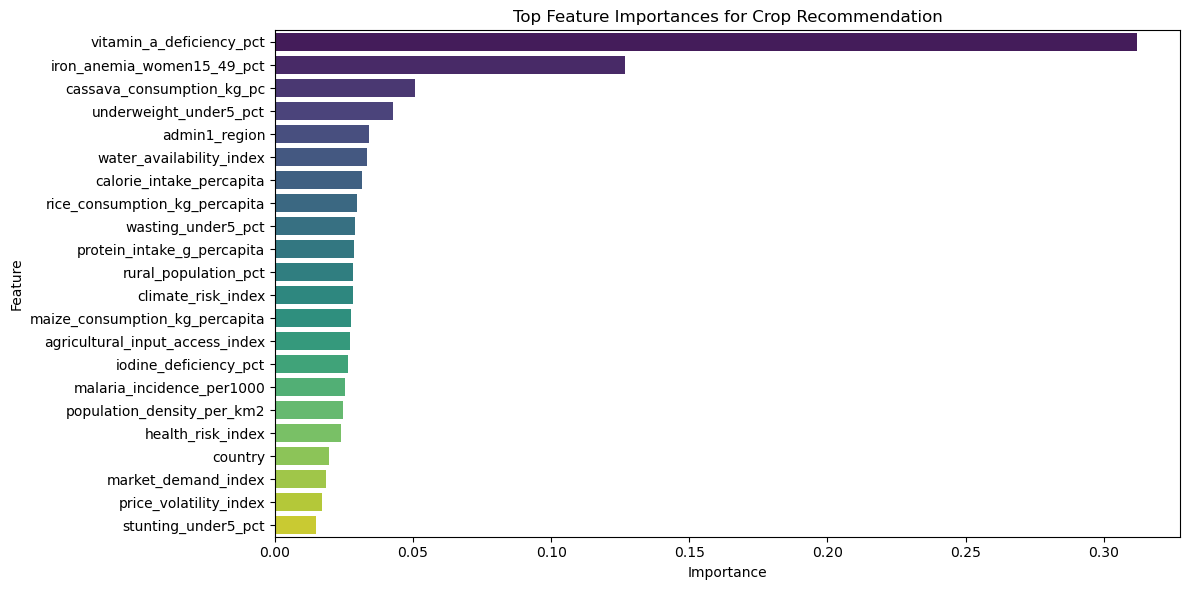

In [15]:
#Feature importance 

import matplotlib.pyplot as plt
import seaborn as sns
 

# Get feature importances from the Random Forest model
importances = model.feature_importances_
features = X.columns

# Sort and plot
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top Feature Importances for Crop Recommendation')
plt.tight_layout()
plt.show()


In [16]:
#doing decoding to know the recommedation crop 
# Your model returns a number like 5
encoded_prediction = 5

# Use inverse_transform to decode it
crop_name = le_crop.inverse_transform([encoded_prediction])
print("Recommended Crop:", crop_name[0])


Recommended Crop: Spinach
